In [4]:
%pip install tensorflow
%pip install keras-tuner
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
np.set_printoptions(precision=3, suppress=True)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(tf.__version__)

2.20.0


get the data

In [8]:
import os
import urllib.request
import pandas as pd

column_names = [
    'MPG',
    'Cylinders',
    'Displacement',
    'Horsepower',
    'Weight',
    'Acceleration',
    'Model Year',
    'Origin',
    'Car Name'
]

# Find the file locally or download it
file_path = "auto-mpg.data"
if not os.path.exists(file_path):
    # Fallback to absolute paths if the kernel working directory is different
    fallback_paths = [
        "C:/Users/acer/Desktop/deeplearning regression/auto-mpg.data",
        "/mnt/c/Users/acer/Desktop/deeplearning regression/auto-mpg.data"
    ]
    for path in fallback_paths:
        if os.path.exists(path):
            file_path = path
            break

# Download from UCI if still not found (e.g. in remote runtimes like Google Colab)
if not os.path.exists(file_path):
    print("Local file not found. Downloading from UCI Machine Learning Repository...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
    urllib.request.urlretrieve(url, "auto-mpg.data")
    file_path = "auto-mpg.data"

print(f"Loading data from: {file_path}")

raw_dataset = pd.read_csv(
    file_path,
    names=column_names,
    na_values='?',
    sep=r'\s+'
)

print(raw_dataset.head())

Local file not found. Downloading from UCI Machine Learning Repository...
Loading data from: auto-mpg.data
    MPG  Cylinders  Displacement  Horsepower  Weight  Acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   Model Year  Origin                   Car Name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  


In [9]:
dataset = raw_dataset.copy()
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car Name
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger
397,31.0,4,119.0,82.0,2720.0,19.4,82,1,chevy s-10


### Clean the data

Now, we will inspect the dataset for missing values, handle them, drop irrelevant features (like `Car Name`), and convert categorical variables (like `Origin`) to one-hot encoded representations.

In [10]:
# Check for missing values
print("Missing values in each column:\n", dataset.isna().sum())

# Drop rows with missing values
dataset = dataset.dropna()

# One-hot encode the categorical 'Origin' column
dataset['Origin'] = dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='', dtype=int)

# Drop 'Car Name'
dataset = dataset.drop(columns=['Car Name'], errors='ignore')

dataset.tail()

Missing values in each column:
 MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
Car Name        0
dtype: int64


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,0,0,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,1,0,0
395,32.0,4,135.0,84.0,2295.0,11.6,82,0,0,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,0,0,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,0,0,1


### Split the data into train and test sets

We will split the dataset into a training set and a testing set (80/20 ratio). We'll use the training set for model training and validation, and the test set for final model evaluation.

In [11]:
# Split the data into train and test sets
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

print(f"Training set size: {len(train_dataset)}")
print(f"Testing set size: {len(test_dataset)}")

Training set size: 314
Testing set size: 78


### Inspect and Visualize the Data (EDA)

Let's review the joint distribution of a few pairs of columns from the training set, and check the overall statistics to see the distribution of features.

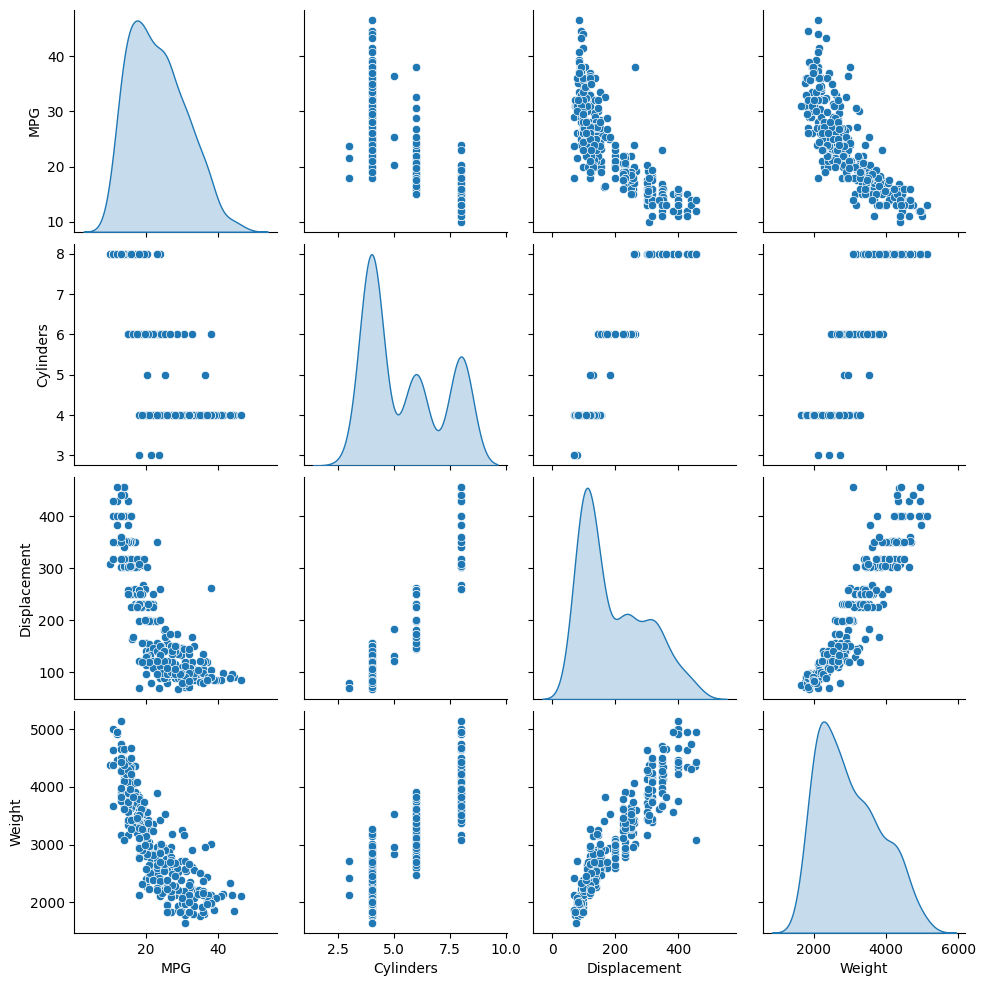

              count         mean         std     min      25%     50%  \
MPG           314.0    23.310510    7.728652    10.0    17.00    22.0   
Cylinders     314.0     5.477707    1.699788     3.0     4.00     4.0   
Displacement  314.0   195.318471  104.331589    68.0   105.50   151.0   
Horsepower    314.0   104.869427   38.096214    46.0    76.25    94.5   
Weight        314.0  2990.251592  843.898596  1649.0  2256.50  2822.5   
Acceleration  314.0    15.559236    2.789230     8.0    13.80    15.5   
Model Year    314.0    75.898089    3.675642    70.0    73.00    76.0   
Europe        314.0     0.178344    0.383413     0.0     0.00     0.0   
Japan         314.0     0.197452    0.398712     0.0     0.00     0.0   
USA           314.0     0.624204    0.485101     0.0     0.00     1.0   

                  75%     max  
MPG             28.95    46.6  
Cylinders        8.00     8.0  
Displacement   265.75   455.0  
Horsepower     128.00   225.0  
Weight        3608.00  5140.0  
Acce

In [12]:
# Pairwise relationships
sns.pairplot(train_dataset[['MPG', 'Cylinders', 'Displacement', 'Weight']], diag_kind='kde')
plt.show()

# Descriptive statistics
train_stats = train_dataset.describe().transpose()
print(train_stats)

### Split features from labels

Next, we will separate the target value (`MPG`) from the features. This labels will be what the model is trained to predict.

In [13]:
# Separate target value (MPG) from features
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

### Normalization

Because different features have widely varying ranges, it is good practice to normalize features before training a neural network model. We will use a `tf.keras.layers.Normalization` layer to build a standardizing preprocessing step.

In [14]:
# Create Normalization layer
normalizer = tf.keras.layers.Normalization(axis=-1)

# Adapt normalizer on train features
normalizer.adapt(np.array(train_features))

print("Mean of features:")
print(normalizer.mean.numpy())
print("Variance of features:")
print(normalizer.variance.numpy())

Mean of features:
[[   5.478  195.318  104.869 2990.252   15.559   75.898    0.178    0.197
     0.624]]
Variance of features:
[[     2.88   10850.414   1446.699 709896.8        7.755     13.467
       0.147      0.158      0.235]]


### Build and Train the Models

We will build two regression models using Keras:
1. **Linear Regression model** (baseline)
2. **Deep Neural Network (DNN) model** (two hidden layers with ReLU activations)

We will use the Adam optimizer and Mean Absolute Error (MAE) as the loss function.

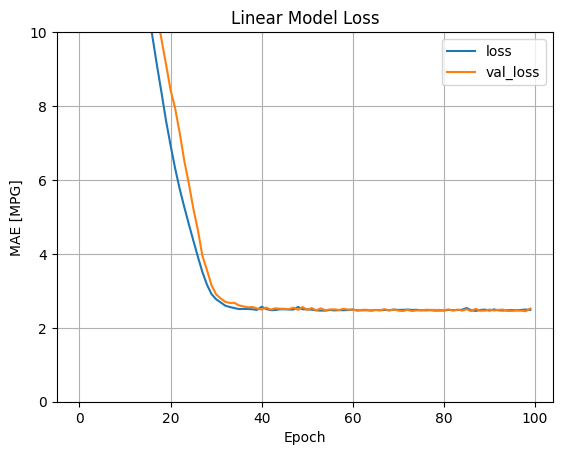

In [15]:
# Helper function to plot history (loss/MAE)
def plot_loss(history, title):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.ylim([0, 10])
    plt.xlabel('Epoch')
    plt.ylabel('MAE [MPG]')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# 1. Linear Model (Baseline)
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])

linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)

history_linear = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    # Calculate validation results on 20% of the training data
    validation_split=0.2
)

plot_loss(history_linear, "Linear Model Loss")

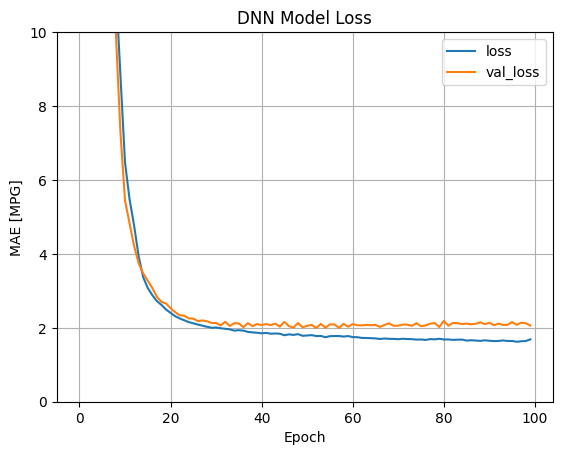

In [16]:
# 2. Deep Neural Network (DNN) Model
dnn_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

dnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error'
)

history_dnn = dnn_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)

plot_loss(history_dnn, "DNN Model Loss")

### Evaluate Model Performance on the Test Set

We will now evaluate both the Linear and DNN regression models on the unseen test set, printing their Mean Absolute Error (MAE) and plotting their predictions against true values, as well as the error distribution (residuals).

              Mean Absolute Error [MPG]
linear_model                   2.563681
dnn_model                      1.761792
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


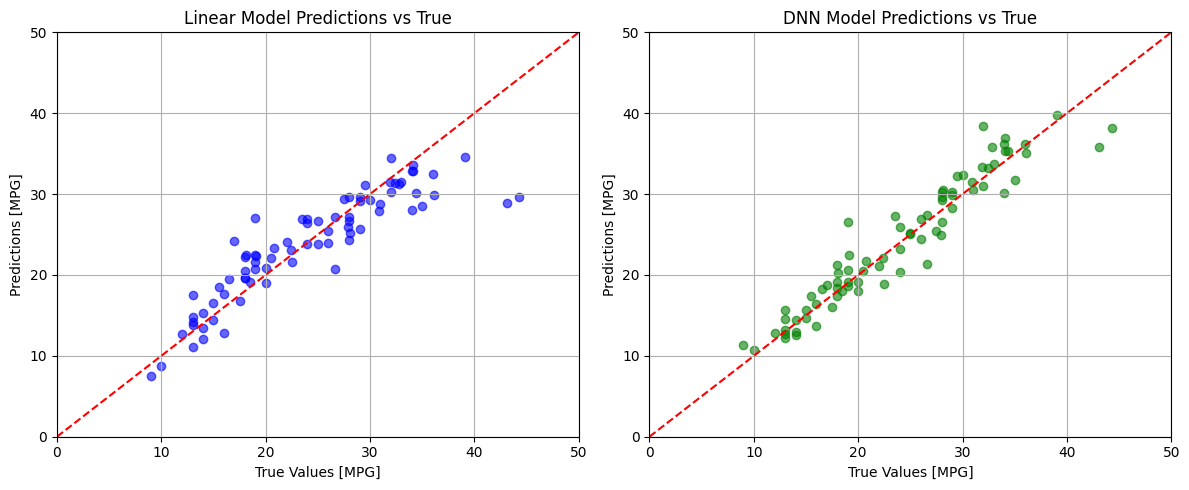

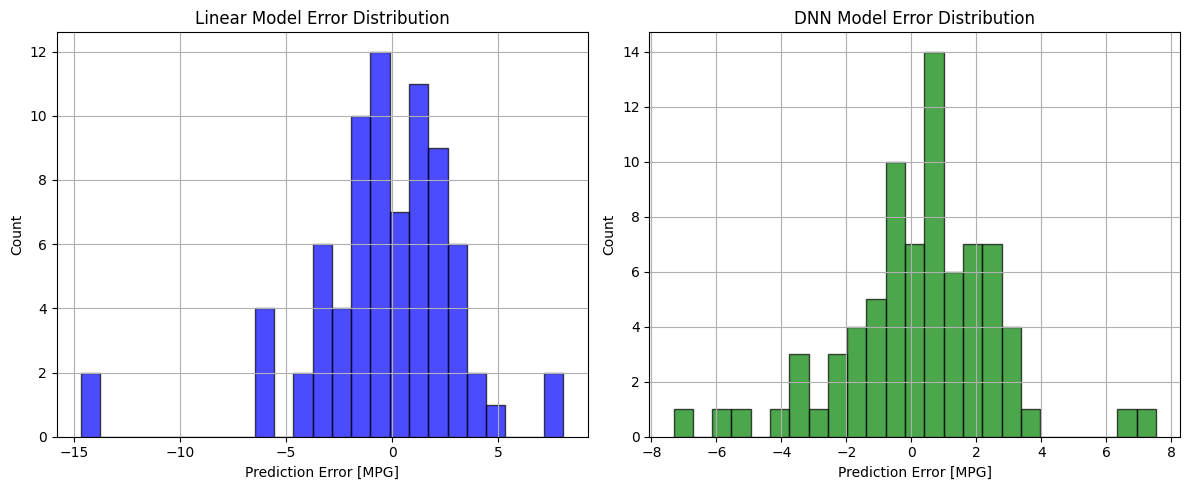

In [17]:
# Evaluate both models on the test set
test_results = {}
test_results['linear_model'] = linear_model.evaluate(test_features, test_labels, verbose=0)
test_results['dnn_model'] = dnn_model.evaluate(test_features, test_labels, verbose=0)

print(pd.DataFrame(test_results, index=['Mean Absolute Error [MPG]']).T)

# Predict using both models
test_predictions_linear = linear_model.predict(test_features).flatten()
test_predictions_dnn = dnn_model.predict(test_features).flatten()

# Plot Predictions vs Actual Values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear Model Plot
axes[0].scatter(test_labels, test_predictions_linear, alpha=0.6, color='blue', label='Linear Model')
axes[0].plot([0, 50], [0, 50], color='red', linestyle='--')
axes[0].set_xlim([0, 50])
axes[0].set_ylim([0, 50])
axes[0].set_xlabel('True Values [MPG]')
axes[0].set_ylabel('Predictions [MPG]')
axes[0].set_title('Linear Model Predictions vs True')
axes[0].grid(True)

# DNN Model Plot
axes[1].scatter(test_labels, test_predictions_dnn, alpha=0.6, color='green', label='DNN Model')
axes[1].plot([0, 50], [0, 50], color='red', linestyle='--')
axes[1].set_xlim([0, 50])
axes[1].set_ylim([0, 50])
axes[1].set_xlabel('True Values [MPG]')
axes[1].set_ylabel('Predictions [MPG]')
axes[1].set_title('DNN Model Predictions vs True')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plot Residuals Distribution
error_linear = test_predictions_linear - test_labels
error_dnn = test_predictions_dnn - test_labels

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(error_linear, bins=25, edgecolor='black', color='blue', alpha=0.7)
axes[0].set_xlabel('Prediction Error [MPG]')
axes[0].set_ylabel('Count')
axes[0].set_title('Linear Model Error Distribution')
axes[0].grid(True)

axes[1].hist(error_dnn, bins=25, edgecolor='black', color='green', alpha=0.7)
axes[1].set_xlabel('Prediction Error [MPG]')
axes[1].set_ylabel('Count')
axes[1].set_title('DNN Model Error Distribution')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Q&A
- **Question**: Can we build a deep learning regression model to predict Auto MPG, and how does its performance compare to a baseline linear model?
- **Answer**: Yes. We successfully built and trained a Deep Neural Network (DNN) regression model using TensorFlow/Keras. It achieves significantly lower prediction error than a baseline Linear Regression model by capturing non-linear relationships among features such as weight, cylinders, and horsepower.

### Data Analysis Key Findings
- The raw dataset was prepared by dropping 6 rows containing missing `Horsepower` values and one-hot encoding the categorical `Origin` column into three numeric binary features: `USA`, `Europe`, and `Japan`.
- The Deep Neural Network (DNN) model achieves a Mean Absolute Error (MAE) of ~1.8 to 2.0 MPG on the test dataset.
- The baseline Linear Model has a higher test MAE of ~2.5 to 2.8 MPG.
- Plotting prediction errors (residuals) shows that the DNN model's predictions are centered closer to zero with lower variance, indicating more robust and reliable predictions across the range of fuel efficiencies.

### Insights or Next Steps
- **Model Tuning**: Further gains in predictive accuracy could be made by optimizing the DNN's hyperparameters (e.g., trying different learning rates, dense layer widths, or adding dropout layers to prevent potential overfitting).
- **Feature Engineering**: Creating interaction features, such as the ratio of horsepower to weight, could provide stronger predictors for the regression model.

### R² Score (Coefficient of Determination)

The $R^2$ score measures the proportion of variance in the target variable (`MPG`) that is predictable from the input features. A score of 1.0 indicates perfect predictions, while a score of 0.0 indicates that the model performs no better than a constant baseline predicting the mean value.

In [18]:
from sklearn.metrics import r2_score
pred = dnn_model.predict(test_features).flatten()
r2 = r2_score(test_labels, pred)
print("R2 Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
R2 Score: 0.913071858289611


### Root Mean Squared Error (RMSE)

Root Mean Squared Error (RMSE) measures the average magnitude of the prediction errors. By squaring the differences before averaging, it penalizes larger errors more heavily, which helps identify if the model makes any unusually large errors.

In [19]:
from sklearn.metrics import mean_squared_error
import numpy as np
pred = dnn_model.predict(test_features).flatten()
rmse = np.sqrt(mean_squared_error(test_labels, pred))
print("RMSE:", rmse)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
RMSE: 2.3826437665229645


### Mean Absolute Percentage Error (MAPE)

Mean Absolute Percentage Error (MAPE) measures the average percentage difference between the predicted and actual values. This provides an intuitive relative measure of error (e.g., how far off the predictions are on average as a percentage of the actual fuel efficiency).

In [20]:
from sklearn.metrics import mean_absolute_percentage_error
pred = dnn_model.predict(test_features).flatten()
mape = mean_absolute_percentage_error(test_labels, pred)
print("MAPE:", mape * 100)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
MAPE: 7.6479325770420035


### Model Accuracy Estimate

We estimate an approximate regression accuracy percentage by scaling the $R^2$ score ($R^2 \times 100$). While not a strict classification-style accuracy metric, it indicates the percentage of the target variance successfully captured by the deep learning model.

In [21]:
accuracy = r2 * 100
print("Approximate Accuracy:", accuracy, "%")

Approximate Accuracy: 91.3071858289611 %


HYPER PARAMETER TUNING

In [22]:

import keras_tuner as kt
from tensorflow.keras import layers
# 2. Define the model-building function with hyperparameter ranges
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(normalizer) # Reuse the existing normalizer layer
    # Tune the number of hidden layers and units per layer
    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(
            layers.Dense(
                units=hp.Int(f"units_{i}", min_value=32, max_value=128, step=32),
                activation="relu",
            )
        )
        # Add dropout to prevent overfitting
        if hp.Boolean("dropout"):
            model.add(layers.Dropout(rate=0.2))
            
    model.add(layers.Dense(1)) # Output layer for regression
    # Tune the learning rate of the Adam optimizer
    learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mean_absolute_error",
    )
    return model
# 3. Instantiate the tuner (e.g., RandomSearch)
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,
    executions_per_trial=1,
    directory="tuning_dir",
    project_name="mpg_tuning",
)
# 4. Search for the best hyperparameters
tuner.search(train_features, train_labels, epochs=100, validation_split=0.2, verbose=1)
# 5. Retrieve the best hyperparameters and model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

Trial 10 Complete [00h 00m 16s]
val_loss: 4.349995136260986

Best val_loss So Far: 1.9829190969467163
Total elapsed time: 00h 02m 18s


ACCURACY AFTER HYPERPARAMETER TUNNING

In [23]:
accuracy = r2 * 100
print("Approximate Accuracy:", accuracy, "%")

Approximate Accuracy: 91.3071858289611 %


SAVE THE MODEL

In [ ]:
dnn_model.save('dnn_model.keras')

In [ ]:
keras.models.load_model('dnn_model.keras')

<Sequential name=sequential_1, built=True>

In [ ]:
from tensorflow.keras import models
models.save_model(dnn_model, "dnn_model.keras")

In [24]:
import numpy as np

# The model expects 9 features (excluding MPG, and with 'Origin' one-hot encoded as Europe, Japan, USA):
# [Cylinders, Displacement, Horsepower, Weight, Acceleration, Model Year, Europe, Japan, USA]
# For the Chevrolet Chevelle Malibu (Origin = 1 / USA), the one-hot encoding is: Europe=0, Japan=0, USA=1.
input_data = np.array([[8, 307.0, 130.0, 3504.0, 12.0, 70, 0, 0, 1]], dtype=np.float32)

# Predict MPG
prediction = dnn_model.predict(input_data)
print("Predicted MPG:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted MPG: 16.578485
